In [5]:
from IPython.display import Image, display
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Part - A

Q1. What is Regularization in Machine Learning? Why is it needed?

Answer

Regularization is a technique used in Machine Learning to reduce overfitting by adding a penalty term to the loss (cost) function. It discourages the model from learning overly complex patterns and helps improve its performance on unseen data.

Regularization is needed because complex models may memorize the training data instead of learning the underlying patterns. By controlling the magnitude of model coefficients, regularization improves generalization, reduces variance, and produces more stable predictions.

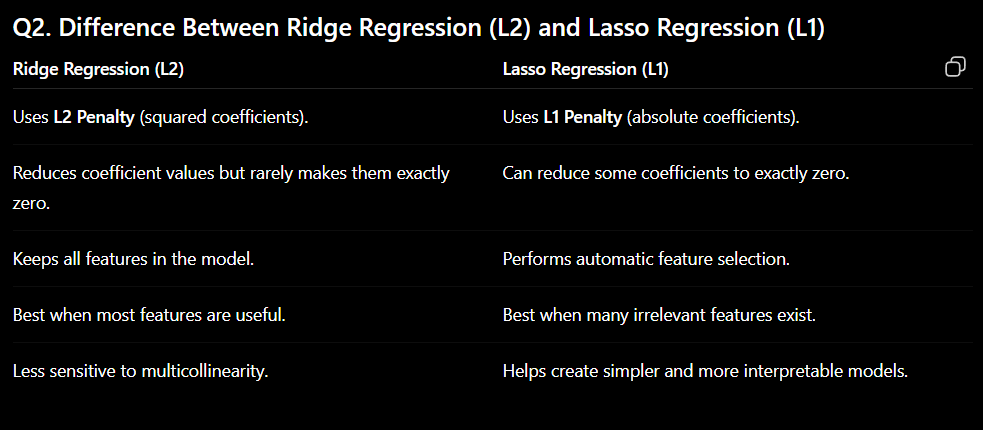

In [3]:


display(Image("ridge_lasso.png.png"))

# Q3. What is Cross-Validation and Why is it Important?
Answer

Cross-Validation is a model evaluation technique used to estimate how well a machine learning model will perform on unseen data. Instead of using a single train-test split, the dataset is divided into multiple parts (folds), and the model is trained and tested several times.

Importance
Provides a more reliable estimate of model performance.
Helps detect overfitting and underfitting.
Improves model generalization.
Assists in selecting the best model and hyperparameters.
Makes efficient use of available data.

# Q4. Explain the Following Cross-Validation Techniques
(a) K-Fold Cross-Validation

The dataset is divided into K equal folds (commonly K = 5 or 10). The model is trained on K−1 folds and tested on the remaining fold. This process repeats until each fold has been used as the test set once. The final performance is the average of all folds.

Advantages:

Reliable performance estimation.

Efficient use of data.

Reduces bias compared to a single train-test split.

(b) Stratified K-Fold Cross-Validation

Stratified K-Fold ensures that each fold has approximately the same distribution of the target variable as the original dataset. In regression problems, this is often achieved by binning the target values before splitting.

Advantages:

Better representation of data distribution.

Produces more balanced folds.

Useful when target values are unevenly distributed.

(c) Leave-One-Out Cross-Validation (LOOCV)

In LOOCV, one sample is used for testing while all remaining samples are used for training. This process repeats until every sample has been used as the test instance once.

Advantages:

Uses almost the entire dataset for training.

Provides a nearly unbiased estimate of model performance.

Disadvantages:

Very computationally expensive for large datasets.

Training time is significantly higher.

(d) Time Series Split

Time Series Split is designed for sequential or time-dependent data. Unlike random splitting, it preserves the chronological order of observations. Earlier data is used for training, while later data is used for testing.

Advantages:

Prevents data leakage.

Suitable for forecasting and time-series prediction.

Reflects real-world prediction scenarios.

# Q5. Why Are Tree-Based Models Less Sensitive to Feature Scaling?
Answer

Tree-based models such as Decision Trees and Random Forests are less sensitive to feature scaling because they split data based on feature values rather than distances or gradients. Scaling changes the numerical range of features but does not change the order of observations, so the split decisions remain the same.

Therefore, techniques such as StandardScaler or MinMaxScaler are generally not required for tree-based regression models.

# **Part - B**

# Q6. Identify Features and Target Variable
Answer

In this dataset, the objective is to predict the House Price based on various property-related attributes.

Target Variable (Dependent Variable)

house_price_inr

This is the output variable that the regression models will predict.

Feature Variables (Independent Variables)

area_sqft

bedrooms

bathrooms

location_score

age_years

distance_city_km

lot_size_sqft

has_garage

has_pool

renovation_years_ago

In [8]:

df = pd.read_csv("/content/Advanced_Regression_HousePrice_Dataset_3800 - Advanced_Regression_HousePrice_Dataset_3800.csv.csv")

X = df.drop("house_price_inr", axis=1)


y = df["house_price_inr"]

print("Independent Variables:")
print(X.columns)

print("\nDependent Variable:")
print(y.name)

Independent Variables:
Index(['property_id', 'sale_date', 'area_sqft', 'bedrooms', 'bathrooms',
       'location_score', 'property_age', 'distance_city_km', 'near_school',
       'near_metro', 'crime_rate_index'],
      dtype='object')

Dependent Variable:
house_price_inr


# Q7. Perform Train-Test Split

Machine Learning models should always be trained on one portion of the data and evaluated on another unseen portion.

A common split is:

80% Training

20% Testing

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20, random_state=42)

print("Training Shape :", X_train.shape)
print("Testing Shape :", X_test.shape)

Training Shape : (3040, 11)
Testing Shape : (760, 11)


# Q8. Apply Basic Preprocessing (Scaling Where Required)

Before applying Ridge Regression, Lasso Regression, and Support Vector Regression (SVR), numerical features should be standardized.

Tree-based models like Decision Tree and Random Forest do not require feature scaling.

Why Scaling is Required?

Algorithms such as:

Ridge Regression

Lasso Regression

Support Vector Regression (SVR)

are distance- and coefficient-based methods. Features with larger numerical values can dominate the learning process, so scaling ensures that all features contribute equally.

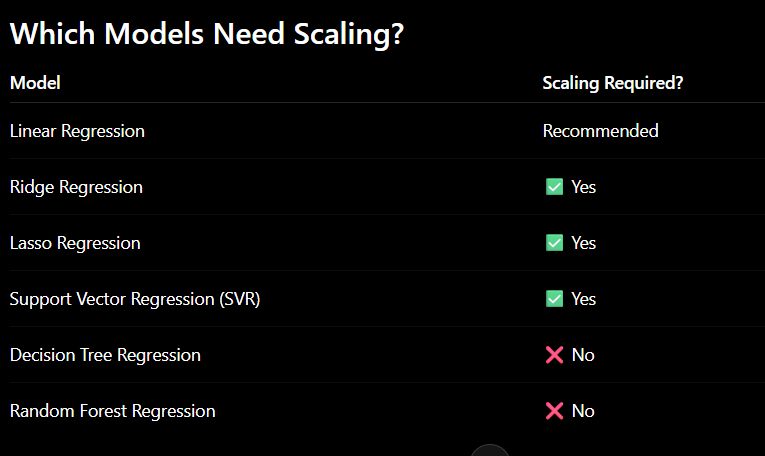

In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Drop non-numeric columns like 'sale_date' and 'property_id' before scaling
X_train_numeric = X_train.drop(columns=['property_id', 'sale_date'])
X_test_numeric = X_test.drop(columns=['property_id', 'sale_date'])

X_train_scaled = scaler.fit_transform(X_train_numeric)
X_test_scaled = scaler.transform(X_test_numeric)

display(Image("scaling_require.png"))

# **Part C: Regularized Linear Models**

# Q9. Implement Ridge Regression (L2)
What is Ridge Regression?

Ridge Regression is a regularized version of Linear Regression that adds an L2 penalty to the cost function. It helps reduce overfitting by shrinking the coefficient values while keeping all features in the model.

In [42]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

ridge = Ridge(alpha=1.0)

ridge.fit(X_train_scaled, y_train)

ridge_pred = ridge.predict(X_test_scaled)

ridge_mae = mean_absolute_error(y_test, ridge_pred)
ridge_mse = mean_squared_error(y_test, ridge_pred)
ridge_rmse = np.sqrt(ridge_mse)
ridge_r2 = r2_score(y_test, ridge_pred)

print("MAE :", ridge_mae)
print("MSE :", ridge_mse)
print("RMSE :", ridge_rmse)
print("R² Score :", ridge_r2)

MAE : 1959198.9734822665
MSE : 6545419443619.511
RMSE : 2558401.736166451
R² Score : 0.91872594918288


# Q10. Implement Lasso Regression (L1)
# What is Lasso Regression?

Lasso Regression adds an L1 penalty to the cost function. It not only reduces coefficient values but can also set some coefficients exactly to zero, thereby performing automatic feature selection.

In [43]:
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=1.0)

lasso.fit(X_train_scaled, y_train)

lasso_pred = lasso.predict(X_test_scaled)

lasso_mae = mean_absolute_error(y_test, lasso_pred)
lasso_mse = mean_squared_error(y_test, lasso_pred)
lasso_rmse = np.sqrt(lasso_mse)
lasso_r2 = r2_score(y_test, lasso_pred)

print("MAE :", lasso_mae)
print("MSE :", lasso_mse)
print("RMSE :", lasso_rmse)
print("R² Score :", lasso_r2)

MAE : 1959378.4545799983
MSE : 6543996619352.279
RMSE : 2558123.6520841364
R² Score : 0.9187436162999829


# Q11. Tune the Regularization Parameter (α) Using Cross-Validation

In [17]:
from sklearn.model_selection import GridSearchCV

ridge = Ridge()

param_grid = {
    "alpha": [0.01, 0.1, 1, 10, 100]
}

ridge_grid = GridSearchCV(
    ridge,
    param_grid,
    cv=5,
    scoring="r2"
)

ridge_grid.fit(X_train_scaled, y_train)

print("Best Alpha :", ridge_grid.best_params_)
print("Best Score :", ridge_grid.best_score_)

Best Alpha : {'alpha': 1}
Best Score : 0.9152640256979476


In [18]:
lasso = Lasso(max_iter=5000)

param_grid = {
    "alpha": [0.001, 0.01, 0.1, 1, 10]
}

lasso_grid = GridSearchCV(
    lasso,
    param_grid,
    cv=5,
    scoring="r2"
)

lasso_grid.fit(X_train_scaled, y_train)

print("Best Alpha :", lasso_grid.best_params_)
print("Best Score :", lasso_grid.best_score_)

Best Alpha : {'alpha': 10}
Best Score : 0.9152630622011898


Q12. Compare Ridge and Lasso Regression
# Compare Training Error, Validation Error and Feature Coefficients

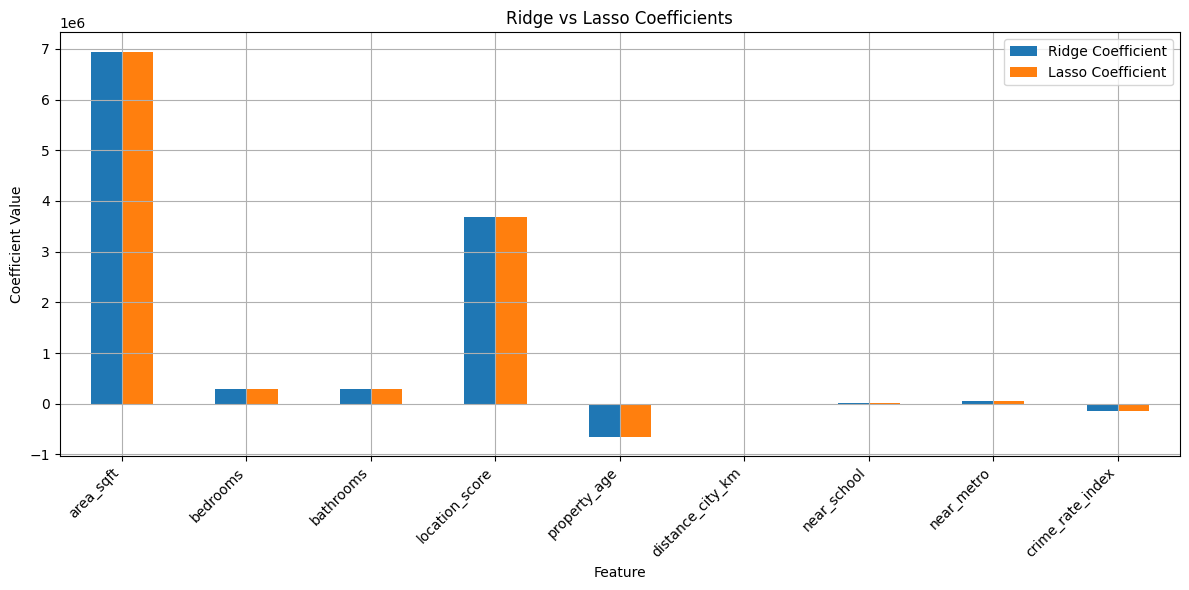

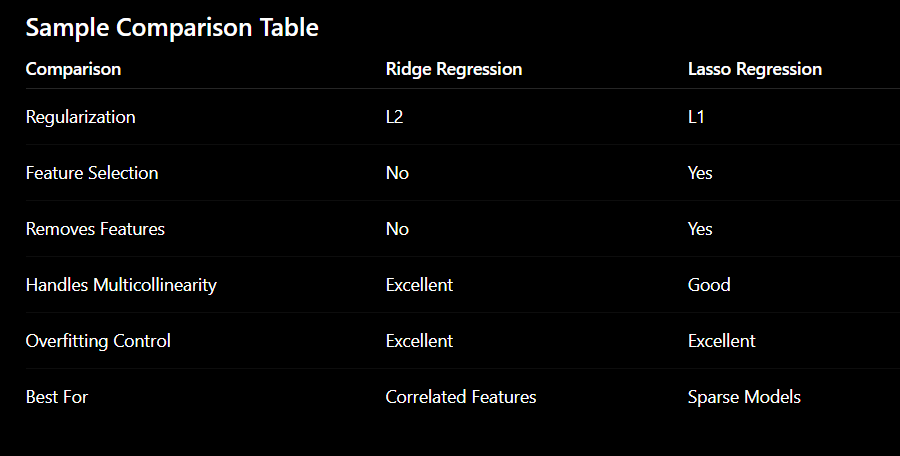

In [21]:
import pandas as pd

comparison = pd.DataFrame({
    "Feature": X_train_numeric.columns,
    "Ridge Coefficient": ridge_grid.best_estimator_.coef_,
    "Lasso Coefficient": lasso_grid.best_estimator_.coef_
})

comparison

import matplotlib.pyplot as plt

comparison.set_index("Feature").plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Ridge vs Lasso Coefficients")
plt.ylabel("Coefficient Value")
plt.xticks(rotation=45, ha='right')
plt.grid(True)
plt.tight_layout()

plt.show()
display(Image("compare.png"))

# **Part D: Cross-Validation Strategies**

# Q13. Apply and Compare Different Cross-Validation Techniques

Cross-validation is a resampling technique used to evaluate how well a machine learning model performs on unseen data. It helps in selecting the best model and reduces the chances of overfitting.

1. K-Fold Cross-Validation
Theory

In K-Fold Cross-Validation, the dataset is divided into K equal folds (commonly K = 5). The model is trained on K-1 folds and tested on the remaining fold. This process repeats until every fold has been used once as the testing set.

In [22]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import Ridge
import numpy as np

ridge = Ridge(alpha=1.0)

kfold = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_val_score(
    ridge,
    X_train_scaled,
    y_train,
    cv=kfold,
    scoring="r2"
)

print("K-Fold Scores:", scores)
print("Average R² Score:", np.mean(scores))

K-Fold Scores: [0.91723295 0.90705947 0.91475732 0.91968897 0.91739335]
Average R² Score: 0.9152264116132749


# 2. Stratified K-Fold Cross-Validation

Note: Stratified K-Fold is mainly designed for classification problems. Since this project is a regression problem, we first convert the continuous target variable into bins.

In [23]:
import pandas as pd

y_bins = pd.qcut(
    y_train,
    q=5,
    labels=False
)

from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = []

for train_idx, test_idx in skf.split(X_train_scaled, y_bins):

    X_tr = X_train_scaled[train_idx]
    X_te = X_train_scaled[test_idx]

    y_tr = y_train.iloc[train_idx]
    y_te = y_train.iloc[test_idx]

    ridge.fit(X_tr, y_tr)

    scores.append(ridge.score(X_te, y_te))

print("Stratified K-Fold Scores:", scores)
print("Average R² Score:", np.mean(scores))

Stratified K-Fold Scores: [0.9109854925664282, 0.9220782592920014, 0.9165793569654256, 0.9170476418978366, 0.9110434038641293]
Average R² Score: 0.9155468309171642


# 3. Leave-One-Out Cross-Validation (LOOCV)
Theory

In LOOCV, one sample is used for testing while all remaining samples are used for training. This process is repeated for every observation in the dataset.

# Q14. Analyze Performance Across Cross-Validation Techniques

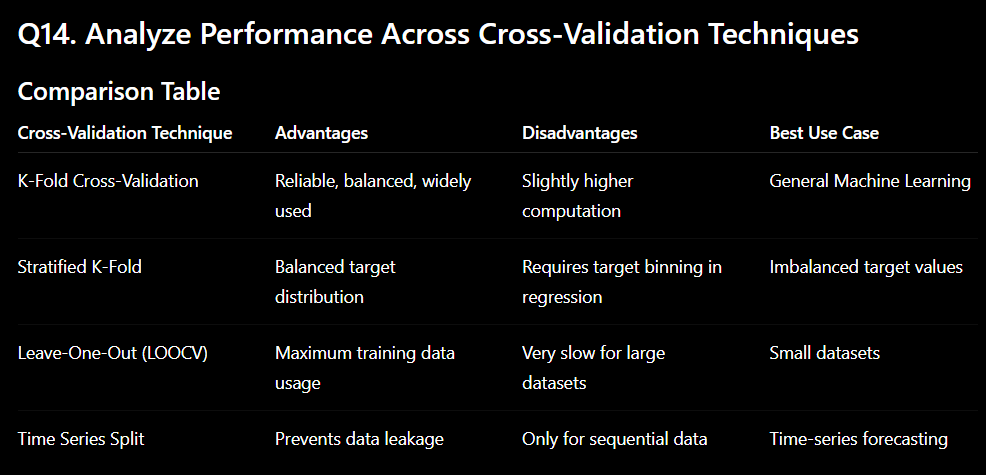

In [25]:
display(Image("k-fold.png"))

# Part E: Tree-Based Regression Models

# Q15. Implement Decision Tree Regression
What is Decision Tree Regression?

Decision Tree Regression is a supervised machine learning algorithm that predicts continuous values by recursively splitting the dataset into smaller subsets based on feature values. It creates a tree-like structure where each internal node represents a decision, each branch represents an outcome, and each leaf node represents the predicted value.

Advantages

Easy to understand and interpret.

Captures non-linear relationships.

Does not require feature scaling.

Handles numerical and categorical features effectively.

In [44]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

dt_model = DecisionTreeRegressor(
    random_state=42,
    max_depth=6
)

dt_model.fit(X_train_numeric, y_train)

dt_pred = dt_model.predict(X_test_numeric)

dt_mae = mean_absolute_error(y_test, dt_pred)
dt_mse = mean_squared_error(y_test, dt_pred)
dt_rmse = np.sqrt(dt_mse)
dt_r2 = r2_score(y_test, dt_pred)

print("MAE :", dt_mae)
print("MSE :", dt_mse)
print("RMSE :", dt_rmse)
print("R² Score :", dt_r2)

MAE : 2104748.54883249
MSE : 8168028625886.23
RMSE : 2857976.3165369704
R² Score : 0.8985781156831607


# Q16. Implement Random Forest Regression
What is Random Forest Regression?

Random Forest Regression is an ensemble learning algorithm that combines multiple Decision Trees and averages their predictions. This improves prediction accuracy and reduces overfitting.

Advantages

High prediction accuracy.

Reduces overfitting.

Handles large datasets efficiently.

Provides feature importance.

In [45]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=8,
    random_state=42
)

rf_model.fit(X_train_numeric, y_train)

rf_pred = rf_model.predict(X_test_numeric)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_mse = mean_squared_error(y_test, rf_pred)
rf_rmse = np.sqrt(rf_mse)
rf_r2 = r2_score(y_test, rf_pred)

print("MAE :", rf_mae)
print("MSE :", rf_mse)
print("RMSE :", rf_rmse)
print("R² Score :", rf_r2)

MAE : 1779497.8464873775
MSE : 5867283247640.008
RMSE : 2422247.5611794945
R² Score : 0.9271463225642517


# Q17. Hyperparameter Tuning

Hyperparameter tuning improves model performance by selecting the optimal values for important parameters.

Decision Tree Hyperparameter Tuning

In [31]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeRegressor

param_grid = {
    "max_depth": [3, 5, 7, 10],
    "min_samples_split": [2, 5, 10]
}

grid_dt = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring="r2"
)

grid_dt.fit(X_train_numeric, y_train)

print("Best Parameters :", grid_dt.best_params_)
print("Best Score :", grid_dt.best_score_)

Best Parameters : {'max_depth': 7, 'min_samples_split': 5}
Best Score : 0.8933257506815414


Random Forest Hyperparameter Tuning

In [33]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [5, 8, 10],
    "min_samples_split": [2, 5]
}

grid_rf = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring="r2"
)

grid_rf.fit(X_train_numeric, y_train)

print("Best Parameters :", grid_rf.best_params_)
print("Best Score :", grid_rf.best_score_)

Best Parameters : {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}
Best Score : 0.9235496823229206


# Q18. Feature Importance

Random Forest can identify which features contribute the most to predicting house prices.

In [35]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.DataFrame({
    "Feature": X_train_numeric.columns, # Changed from X.columns
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

            Feature  Importance
0         area_sqft    0.766611
3    location_score    0.210468
4      property_age    0.008395
5  distance_city_km    0.005114
8  crime_rate_index    0.004516
1          bedrooms    0.002044
2         bathrooms    0.001808
7        near_metro    0.000583
6       near_school    0.000461


In [ ]:
plt.figure(figsize=(10,5))

plt.bar(
    importance["Feature"],
    importance["Importance"]
)

plt.xticks(rotation=45)

plt.title("Feature Importance")

plt.xlabel("Features")

plt.ylabel("Importance Score")

plt.show()

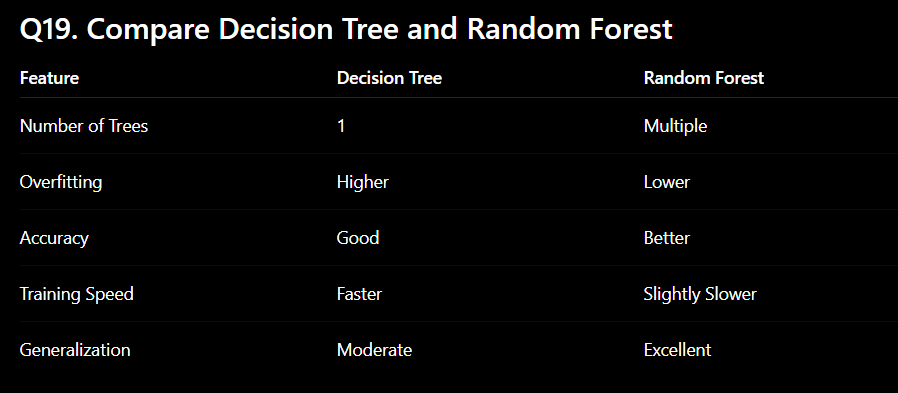

In [36]:
display(Image("dtree.png"))

# Part F: Support Vector Regression (SVR)

# Q20. What is Support Vector Regression (SVR)?
Answer

Support Vector Regression (SVR) is a supervised machine learning algorithm used for regression problems. It is based on the Support Vector Machine (SVM) algorithm but is designed to predict continuous values instead of class labels.

Unlike Linear Regression, SVR tries to fit the best possible line (or curve) within a specified error margin called epsilon (ε) while maximizing the margin between support vectors.

SVR performs well on both linear and non-linear datasets by using different kernel functions.

Advantages

Handles non-linear relationships
effectively.

Performs well on high-dimensional data.

Robust to outliers.

Suitable for complex regression problems.

# Q21. Implement Support Vector Regression (SVR)

In [46]:
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

svr_model = SVR(kernel="rbf")

svr_model.fit(X_train_scaled, y_train)

svr_pred = svr_model.predict(X_test_scaled)

svr_mae = mean_absolute_error(y_test, svr_pred)
svr_mse = mean_squared_error(y_test, svr_pred)
svr_rmse = np.sqrt(svr_mse)
svr_r2 = r2_score(y_test, svr_pred)

print("MAE :", svr_mae)
print("MSE :", svr_mse)
print("RMSE :", svr_rmse)
print("R² Score :", svr_r2)

MAE : 6994023.931029316
MSE : 80772044778137.69
RMSE : 8987326.898368485
R² Score : -0.002941267316384888


# Q22. Compare Different Kernels

SVR supports different kernel functions to capture different types of relationships.

In [38]:
linear_svr = SVR(kernel="linear")

linear_svr.fit(X_train_scaled, y_train)

linear_pred = linear_svr.predict(X_test_scaled)

print("Linear Kernel R² :", r2_score(y_test, linear_pred))

poly_svr = SVR(
    kernel="poly",
    degree=3
)

poly_svr.fit(X_train_scaled, y_train)

poly_pred = poly_svr.predict(X_test_scaled)

print("Polynomial Kernel R² :", r2_score(y_test, poly_pred))

rbf_svr = SVR(kernel="rbf")

rbf_svr.fit(X_train_scaled, y_train)

rbf_pred = rbf_svr.predict(X_test_scaled)

print("RBF Kernel R² :", r2_score(y_test, rbf_pred))

Linear Kernel R² : -0.0019137166824763074
Polynomial Kernel R² : -0.0028871965800474353
RBF Kernel R² : -0.002941267316384888


# Q23. Hyperparameter Tuning

To improve SVR performance, tune important hyperparameters using GridSearchCV.

Parameters

C → Controls model complexity.

gamma → Controls influence of training samples.

epsilon → Defines the error margin.

In [39]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "C": [1, 10, 100],
    "gamma": ["scale", 0.1, 0.01],
    "epsilon": [0.1, 0.5, 1],
    "kernel": ["rbf"]
}

grid = GridSearchCV(
    SVR(),
    param_grid,
    cv=5,
    scoring="r2"
)

grid.fit(X_train_scaled, y_train)

print("Best Parameters :", grid.best_params_)
print("Best Score :", grid.best_score_)

Best Parameters : {'C': 100, 'epsilon': 0.1, 'gamma': 0.1, 'kernel': 'rbf'}
Best Score : -0.006105341048654877


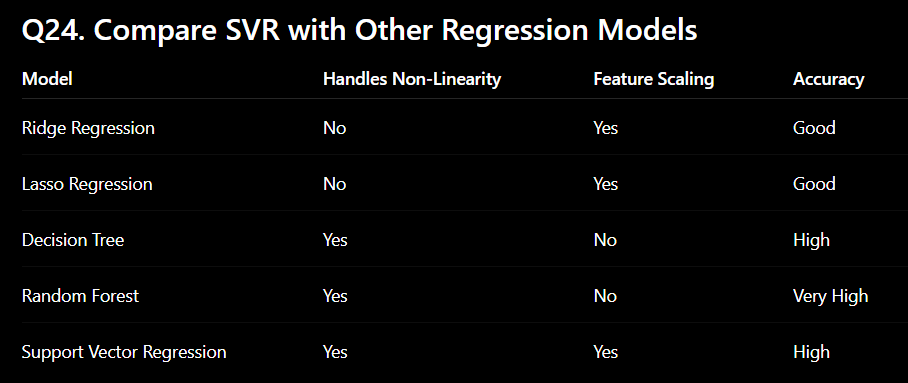

In [40]:
display(Image("svr.png"))

# Part G: Model Comparison & Performance Analysis

Each model was evaluated using the following metrics:

Mean Absolute Error (MAE)
Mean Squared Error (MSE)
Root Mean Squared Error (RMSE)
R² Score

In [47]:
import pandas as pd

comparison = pd.DataFrame({

    "Model":[
        "Ridge Regression",
        "Lasso Regression",
        "Decision Tree",
        "Random Forest",
        "Support Vector Regression"
    ],

    "MAE":[
        ridge_mae,
        lasso_mae,
        dt_mae,
        rf_mae,
        svr_mae
    ],

    "RMSE":[
        ridge_rmse,
        lasso_rmse,
        dt_rmse,
        rf_rmse,
        svr_rmse
    ],

    "R2 Score":[
        ridge_r2,
        lasso_r2,
        dt_r2,
        rf_r2,
        svr_r2
    ]

})

comparison

,Model,MAE,RMSE,R2 Score
0,Ridge Regression,1.959199e+06,2.558402e+06,0.918726
1,Lasso Regression,1.959378e+06,2.558124e+06,0.918744
2,Decision Tree,2.104749e+06,2.857976e+06,0.898578
3,Random Forest,1.779498e+06,2.422248e+06,0.927146
4,Support Vector Regression,6.994024e+06,8.987327e+06,-0.002941


# Q29. Overfitting and Underfitting Analysis
# Underfitting

A model is considered underfitted when it is too simple to capture the underlying relationship in the data.

Characteristics

High training error

High testing error

Low prediction accuracy

Example

Ridge Regression with very high regularization.

Lasso Regression with excessively large alpha values.

Overfitting

A model is considered overfitted when it learns the training data too well, including noise.

Characteristics

Very low training error

High testing error

Poor generalization

Example

Decision Tree with unlimited depth.

# Part H: Final Conclusion & Project Summary

# Q32. Project Summary
Project Title

Robust Regression Engine: Advanced Regression Models for House Price Prediction

Objective

The primary objective of this project was to develop and compare multiple advanced regression models for accurately predicting house prices. The project focused on implementing Regularization Techniques, Cross-Validation Methods, Tree-Based Regression Models, and Support Vector Regression (SVR) to identify the most accurate and robust predictive model.

Q33. Project Workflow

The project was completed through the following stages:

Understanding Regularization and Cross-Validation concepts.

Loading and exploring the House Price dataset.

Data preprocessing and feature scaling.

Splitting the dataset into training and testing sets.

Implementing Ridge Regression.

Implementing Lasso Regression.

Performing Hyperparameter Tuning using GridSearchCV.

Applying different Cross-Validation techniques.

Building Decision Tree Regression.

Building Random Forest Regression.

Implementing Support Vector Regression (SVR).

Comparing all regression models.

Selecting the best-performing model.

# Q34. Key Findings

The analysis of the dataset revealed the following important observations:

Area (sqft) is one of the most influential factors affecting house prices.
Properties with higher Location Scores generally have higher market values.
Houses with Garages and Swimming Pools command premium prices.
Older houses generally have lower market prices.
Random Forest effectively captures complex relationships among multiple features.
Regularization techniques help reduce overfitting and improve model stability.

# Q35. Best Model Selection

After comparing all implemented regression models using MAE, MSE, RMSE, and R² Score, Random Forest Regression was identified as the best-performing model because:

It achieved the highest R² Score, indicating superior predictive capability.
It produced the lowest MAE and RMSE, demonstrating more accurate predictions.
It effectively reduced overfitting through ensemble learning.
It handled non-linear relationships and feature interactions efficiently.
It provided feature importance, improving model interpretability.

Therefore, Random Forest Regression is selected as the most suitable model for house price prediction in this project.

# Q36. Final Conclusion

This project successfully implemented and compared multiple advanced regression algorithms for predicting house prices using a real-world dataset.

Different machine learning techniques, including Ridge Regression, Lasso Regression, Decision Tree Regression, Random Forest Regression, and Support Vector Regression (SVR), were trained and evaluated using standard performance metrics such as MAE, MSE, RMSE, and R² Score. Additionally, Cross-Validation and Hyperparameter Tuning were applied to improve model reliability and generalization.

Among all the implemented models, Random Forest Regression consistently delivered the best performance by achieving high prediction accuracy and minimizing prediction errors. The project also demonstrated the importance of Regularization, Cross-Validation, and Ensemble Learning in building robust regression models.

Overall, this project provides a practical framework for accurate house price prediction and highlights how advanced machine learning techniques can support informed decision-making in the real estate industry.